In [ ]:
# @title 폰트 설치 및 Matplotlib 설정 (한글 깨짐 방지)
# 런타임 재시작 필요 없음

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 나눔 폰트 설치 및 Matplotlib 설정 완료.")
print("이제 시각화 셀을 다시 실행하시면 한글이 정상적으로 표시됩니다.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

# **데이터 수집 - BBQ**

In [ ]:
# [셀 1] 필수 라이브러리 설치 및 임포트
!pip install google-api-python-client pandas openpyxl tqdm

import os
import math
import pandas as pd
from googleapiclient.discovery import build
from google.colab import drive, userdata
from tqdm.notebook import tqdm

In [ ]:
# [셀 2] 구글 드라이브 마운트 및 저장 경로 설정 함수
drive.mount('/content/drive')

def create_directory(path):
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"폴더가 생성되었습니다: {path}")
    else:
        print(f"폴더가 이미 존재합니다: {path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# [셀 3] 사용자 설정 변수 (이곳만 수정하세요)

# 1. 수집할 단일 영상의 ID
TARGET_VIDEO_ID = "-KLhKEW-Ku8"

# 2. 데이터를 저장할 폴더 경로
SAVE_FOLDER_PATH = "/content/drive/MyDrive/YoutubeData"

# 3. 저장할 파일 이름 (확장자 .xlsx)
SAVE_FILENAME = "single_video_comments.xlsx"

# 경로 생성 및 최종 경로 확인
create_directory(SAVE_FOLDER_PATH)
FULL_SAVE_PATH = os.path.join(SAVE_FOLDER_PATH, SAVE_FILENAME)
print(f"대상 영상 ID: {TARGET_VIDEO_ID}")
print(f"저장 경로: {FULL_SAVE_PATH}")

폴더가 이미 존재합니다: /content/drive/MyDrive/YoutubeData
대상 영상 ID: -KLhKEW-Ku8
저장 경로: /content/drive/MyDrive/YoutubeData/single_video_comments.xlsx


In [ ]:
# [셀 4] 유튜브 API 연결 및 수집 함수 정의

# API 키 가져오기
try:
    api_key = userdata.get('youtube')
    youtube = build('youtube', 'v3', developerKey=api_key)
    print("API 연결 성공")
except Exception as e:
    print(f"API 연결 실패: {e}\n보안 비밀(Secrets)에 'youtube' 키를 확인해주세요.")

def get_video_details(video_id):
    """영상의 제목, 게시일, 총 댓글 수 등 기본 정보를 가져옵니다."""
    request = youtube.videos().list(
        part='snippet,statistics',
        id=video_id
    )
    response = request.execute()

    if not response['items']:
        return None

    item = response['items'][0]
    return {
        'video_id': video_id,
        'video_title': item['snippet']['title'],
        'video_published_at': item['snippet']['publishedAt'],
        'channel_title': item['snippet']['channelTitle'],
        'view_count': int(item['statistics'].get('viewCount', 0)),
        'total_comment_count': int(item['statistics'].get('commentCount', 0)) # 전체 댓글 수(대댓글 포함)
    }

def fetch_comments_and_save(video_id, video_info, save_path):
    """
    해당 영상의 댓글을 페이지 단위로 수집하여 리스트에 담습니다.
    대량 수집 시 진행률을 보여줍니다.
    """
    comments_data = []
    total_comments = video_info['total_comment_count']

    # 진행바 설정 (예상 댓글 수 기준)
    pbar = tqdm(total=total_comments, desc="댓글 수집 진행률")

    try:
        request = youtube.commentThreads().list(
            part='snippet,replies',
            videoId=video_id,
            maxResults=100, # 한 번 요청에 최대 100개 스레드
            textFormat='plainText'
        )

        while request:
            response = request.execute()

            # 이번 페이지에서 가져온 댓글 수 카운트 (진행바 업데이트용)
            fetched_count_in_page = 0

            for item in response['items']:
                # 1. 최상위 댓글 (Top Level)
                top_comment = item['snippet']['topLevelComment']['snippet']
                comments_data.append({
                    **video_info, # 영상 정보 병합
                    'comment_id': item['id'],
                    'parent_id': None, # 원댓글임
                    'author_name': top_comment['authorDisplayName'],
                    'text': top_comment['textDisplay'],
                    'like_count': top_comment['likeCount'],
                    'published_at': top_comment['publishedAt'],
                    'updated_at': top_comment['updatedAt'],
                    'reply_count': item['snippet']['totalReplyCount']
                })
                fetched_count_in_page += 1

                # 2. 대댓글 (Replies)
                if item['snippet']['totalReplyCount'] > 0:
                    if 'replies' in item:
                        for reply in item['replies']['comments']:
                            rep_snip = reply['snippet']
                            comments_data.append({
                                **video_info,
                                'comment_id': reply['id'],
                                'parent_id': item['id'], # 부모 댓글 ID
                                'author_name': rep_snip['authorDisplayName'],
                                'text': rep_snip['textDisplay'],
                                'like_count': rep_snip['likeCount'],
                                'published_at': rep_snip['publishedAt'],
                                'updated_at': rep_snip['updatedAt'],
                                'reply_count': 0
                            })
                            fetched_count_in_page += 1

            # 진행바 업데이트
            pbar.update(fetched_count_in_page)

            # 다음 페이지 토큰 확인
            if 'nextPageToken' in response:
                request = youtube.commentThreads().list(
                    part='snippet,replies',
                    videoId=video_id,
                    maxResults=100,
                    textFormat='plainText',
                    pageToken=response['nextPageToken']
                )
            else:
                break

    except Exception as e:
        print(f"\n[Error] 댓글 수집 중 오류 발생: {e}")
    finally:
        pbar.close()

    return comments_data

API 연결 성공


In [ ]:
# [셀 4-1] 최근 3개월 '뿜치킹' 리뷰 영상 검색

from datetime import datetime, timedelta, timezone

# 🔧 검색 키워드 (필요하면 추가/수정 가능)
SEARCH_QUERIES = [
    "bbq 뿜치킹 리뷰",
    "bbq 뿜치킹 먹방",
    "비비큐 뿜치킹 리뷰",
    "뿜치킹 신메뉴 리뷰",
]

# 🔧 기간 설정: 최근 3개월
MONTH_RANGE = 3

# 🔧 전체에서 가져올 최대 영상 수 (중복 제거 후 기준 아님, 안전용 상한)
MAX_VIDEOS = 80

# ---- publishedAfter (최근 3개월) 계산: UTC 기준 → RFC3339 ----
now_utc = datetime.now(timezone.utc)
published_after_dt = now_utc - timedelta(days=30 * MONTH_RANGE)
PUBLISHED_AFTER = published_after_dt.isoformat().replace("+00:00", "Z")

print(f"📅 검색 기간: {published_after_dt.date()} ~ {now_utc.date()}")
print(f"📌 검색 키워드: {SEARCH_QUERIES}")

# 검색 결과 저장용 (video_id 기준 중복 제거)
found_videos = {}

for query in SEARCH_QUERIES:
    print(f"\n🔍 키워드 검색 중: '{query}'")
    next_page_token = None
    fetched_for_query = 0

    while True:
        search_request = youtube.search().list(
            part="snippet",
            q=query,
            type="video",
            maxResults=50,
            order="viewCount",        # 조회수 순
            publishedAfter=PUBLISHED_AFTER,
            pageToken=next_page_token
        )
        search_response = search_request.execute()

        for item in search_response.get("items", []):
            video_id = item["id"]["videoId"]
            snippet = item["snippet"]
            title = snippet["title"]
            desc = snippet.get("description", "")

            # ✅ 필수 조건 1: 제목/설명에 '뿜치킹' 포함
            if "뿜치킹" not in title and "뿜치킹" not in desc:
                continue

            # (선택) BBQ 관련 여부를 한 번 더 필터링하고 싶다면 아래 주석 해제
            # title_lower = title.lower()
            # channel_lower = snippet["channelTitle"].lower()
            # if ("bbq" not in title_lower and "비비큐" not in title_lower
            #     and "bbq" not in channel_lower and "비비큐" not in channel_lower):
            #     continue

            if video_id not in found_videos:
                found_videos[video_id] = {
                    "video_id": video_id,
                    "title": title,
                    "channel_title": snippet["channelTitle"],
                    "published_at": snippet["publishedAt"],
                    "search_query": query,
                }
                fetched_for_query += 1

                if len(found_videos) >= MAX_VIDEOS:
                    print("⚠️ MAX_VIDEOS에 도달하여 검색을 중단합니다.")
                    break

        if len(found_videos) >= MAX_VIDEOS:
            break

        next_page_token = search_response.get("nextPageToken")
        if not next_page_token:
            break

    print(f"  ↳ '{query}'로 조건(뿜치킹 포함)을 만족한 영상 수: {fetched_for_query}개")

print("\n✅ 최종 선택된 영상 수(중복 제거 후):", len(found_videos))
for vid, info in list(found_videos.items())[:5]:
    print(f" - {info['title']} | {info['channel_title']} | {info['published_at']}")


📅 검색 기간: 2025-08-30 ~ 2025-11-28
📌 검색 키워드: ['bbq 뿜치킹 리뷰', 'bbq 뿜치킹 먹방', '비비큐 뿜치킹 리뷰', '뿜치킹 신메뉴 리뷰']

🔍 키워드 검색 중: 'bbq 뿜치킹 리뷰'
  ↳ 'bbq 뿜치킹 리뷰'로 조건(뿜치킹 포함)을 만족한 영상 수: 70개

🔍 키워드 검색 중: 'bbq 뿜치킹 먹방'
⚠️ MAX_VIDEOS에 도달하여 검색을 중단합니다.
  ↳ 'bbq 뿜치킹 먹방'로 조건(뿜치킹 포함)을 만족한 영상 수: 10개

🔍 키워드 검색 중: '비비큐 뿜치킹 리뷰'
⚠️ MAX_VIDEOS에 도달하여 검색을 중단합니다.
  ↳ '비비큐 뿜치킹 리뷰'로 조건(뿜치킹 포함)을 만족한 영상 수: 1개

🔍 키워드 검색 중: '뿜치킹 신메뉴 리뷰'
  ↳ '뿜치킹 신메뉴 리뷰'로 조건(뿜치킹 포함)을 만족한 영상 수: 0개

✅ 최종 선택된 영상 수(중복 제거 후): 81
 - SUB)바삭끝판왕 bbq 황금올리브 치킨에 신메뉴 뿜치킹 먹방🍗핫크리스피 새우스틱까지 Chicken Mukbang Asmr | 문복희 Eat with Boki | 2025-10-21T11:00:29Z
 - 이 가게는 곧 K-치맥 성지가 됩니다 🍗ㅣBBQ 치킨 알바ㅣ워크돌ㅣ미야오 안나, 수인 | 워크맨-Workman | 2025-11-06T10:00:44Z
 - BBQ 치킨 신상이 뿌링클을 넘었다고? 바로 먹어봤습니다 | 흑백리뷰 | 2025-09-27T06:00:00Z
 - BBQ뿜치킹은 BHC뿌링클을 이길 수 있을까!? | 잇츠오니 ! (Eat's Oni ) | 2025-10-03T12:32:20Z
 - 비비큐 신메뉴 출시기념 황올 반마리가 공짜? | 과식이 | 2025-09-25T09:38:00Z


In [ ]:
# [셀 4-2] '뿜치킹' + 댓글 150개 이상 영상만 댓글 수집 후 엑셀 저장

MIN_COMMENTS = 150  # ✅ 필수 조건 2: 댓글 150개 이상

print("\n📥 여러 영상의 댓글 수집을 시작합니다...")
print(f"   (조건: 제목/설명에 '뿜치킹' 포함 + 댓글 {MIN_COMMENTS}개 이상)")

all_comments = []

for video_id, meta in tqdm(found_videos.items(), desc="영상별 처리", unit="video"):
    # 1. 영상 기본 정보 가져오기
    video_info = get_video_details(video_id)
    if video_info is None:
        print(f"⚠️ 영상 정보를 가져올 수 없어 스킵: {video_id}")
        continue

    total_comments = video_info["total_comment_count"]

    # ✅ 필수 조건 2: 댓글 개수 필터
    if total_comments < MIN_COMMENTS:
        print(f"❎ [{video_info['video_title']}] → 댓글 {total_comments}개 (200개 미만) → 스킵")
        continue

    print(f"\n🎬 [{video_info['video_title']}] ({video_id})")
    print(f"   채널: {video_info['channel_title']}")
    print(f"   유튜브 표기 댓글 수: {total_comments}개 → 수집 시작")

    # 2. 댓글 수집 (기존 함수 재사용, save_path는 사용 안 하므로 None 전달)
    try:
        comments_data = fetch_comments_and_save(video_id, video_info, save_path=None)
        print(f"   ✔ 수집 완료: {len(comments_data)}개")
        all_comments.extend(comments_data)
    except Exception as e:
        print(f"   ❌ 댓글 수집 중 오류 발생 → 스킵: {e}")

print("\n📊 전체 수집 결과 요약")
print(f"   👉 최종 수집된 댓글 수: {len(all_comments)}개")

if len(all_comments) == 0:
    print("❌ 조건을 만족하는 댓글이 없습니다. 기간/검색어/조건을 다시 확인해 주세요.")
else:
    # DataFrame 변환
    df = pd.DataFrame(all_comments)

    # --- 날짜 컬럼 한국 시간(KST)으로 통일 ---
    def process_datetime(series):
        dt = pd.to_datetime(series)

        # tz 정보가 없으면 UTC로 가정 후 KST 변환
        try:
            if dt.dt.tz is None:
                dt = dt.dt.tz_localize("UTC")
        except AttributeError:
            # 일부 버전에서 dt.dt.tz가 없을 수도 있어 예외 처리
            dt = dt.dt.tz_localize("UTC")

        dt_kst = dt.dt.tz_convert("Asia/Seoul")
        return dt_kst.dt.tz_localize(None)

    print("⏱ 날짜 데이터를 한국 시간으로 변환 중...")

    date_cols = ['published_at', 'updated_at', 'video_published_at']
    for col in date_cols:
        if col in df.columns:
            df[col] = process_datetime(df[col])

    # --- 엑셀 저장 (기존 FULL_SAVE_PATH 재사용) ---
    try:
        df.to_excel(FULL_SAVE_PATH, index=False)
        print("\n💾 엑셀 저장 완료!")
        print(f"   저장 경로: {FULL_SAVE_PATH}")
        print("=" * 50)
        print(f"✅ 최종 수집 댓글 수: {len(df)}개")
        print(f"✅ 조건: '뿜치킹' 포함 영상 + 댓글 {MIN_COMMENTS}개 이상만 반영됨")
        print("=" * 50)
        print("\n--- 데이터 미리보기 (상위 5개) ---")
        print(df.head(5).to_string())
    except Exception as e:
        print(f"\n❌ 엑셀 저장 중 오류 발생: {e}")



📥 여러 영상의 댓글 수집을 시작합니다...
   (조건: 제목/설명에 '뿜치킹' 포함 + 댓글 150개 이상)


영상별 처리:   0%|          | 0/81 [00:00<?, ?video/s]


🎬 [SUB)바삭끝판왕 bbq 황금올리브 치킨에 신메뉴 뿜치킹 먹방🍗핫크리스피 새우스틱까지 Chicken Mukbang Asmr] (IIJ4NoMIKMA)
   채널: 문복희 Eat with Boki
   유튜브 표기 댓글 수: 463개 → 수집 시작


댓글 수집 진행률:   0%|          | 0/463 [00:00<?, ?it/s]

   ✔ 수집 완료: 440개

🎬 [이 가게는 곧 K-치맥 성지가 됩니다 🍗ㅣBBQ 치킨 알바ㅣ워크돌ㅣ미야오 안나, 수인] (O_cGAa6TGFY)
   채널: 워크맨-Workman
   유튜브 표기 댓글 수: 747개 → 수집 시작


...

   ✔ 수집 완료: 187개

🎬 [태어나서 처음 먹어본 가루치킨 삼대장 리뷰 (BBQ 뿜치킹, 네네 스노윙, BHC 뿌링클)] (HE1xTPwuXok)
   채널: 승빠
   유튜브 표기 댓글 수: 255개 → 수집 시작


댓글 수집 진행률:   0%|          | 0/255 [00:00<?, ?it/s]

   ✔ 수집 완료: 239개
❎ [뿌링클만큼 맛있을지도…? 먹방VLOG | 뿜치킹 저당엽닭 인생두바이디저트 연세우유교보문고 편의점말차파티 후와후와 매콤크림떡볶이] → 댓글 46개 (200개 미만) → 스킵
❎ [비비큐 신메뉴 뿜치킹] → 댓글 8개 (200개 미만) → 스킵
❎ [신메뉴 맛집 BBQ] → 댓글 37개 (200개 미만) → 스킵
❎ [요즘 핫하다는 BBQ 신상 치킨 뿜치킹🍗] → 댓글 5개 (200개 미만) → 스킵
❎ [이게 비비큐 프리미엄 가루 치킨? (+ 황금올리브 최신 근황)] → 댓글 134개 (200개 미만) → 스킵
❎ [BBQ 뿜치킹 출시하자마자 먹어본 솔직한 후기! 뿌링클 치킨 보다..] → 댓글 38개 (200개 미만) → 스킵
❎ [무자비한 BBQ 뿜치킹] → 댓글 13개 (200개 미만) → 스킵
❎ [뿜치킹 솔직리뷰] → 댓글 7개 (200개 미만) → 스킵
❎ [BBQ신상 ‘뿜치킹’ 솔직리뷰] → 댓글 3개 (200개 미만) → 스킵
❎ [BBQ 뿜치킹 VS BHC 뿌링클! 승자는 과연...? 🍗🍗] → 댓글 9개 (200개 미만) → 스킵
❎ [그거랑 저거랑 섞은 듯한 맛인데? #비비큐 #신메뉴 뿜치킹] → 댓글 23개 (200개 미만) → 스킵
❎ [BBQ신상 뿜치킨이랑 뿜치킹 콘립 먹어봤어요! 과연 맛은 어떨지?] → 댓글 11개 (200개 미만) → 스킵
❎ [뿌링클 능가하는 BBQ 역대급 신메뉴 뿜치킹 출시] → 댓글 30개 (200개 미만) → 스킵
❎ [뿌링클 좋아하면 무조건 궁금해할 신상치킨🍗           #리뷰 #내돈내산 #먹방 #쇼츠 #치킨 #뿌링클 #뿜치킹] → 댓글 2개 (200개 미만) → 스킵
❎ [비비큐 신상 출시?!] → 댓글 2개 (200개 미만) → 스킵
❎ [BBQ 뿜치킹] → 댓글 35개 (200개 미만) → 스킵
❎ [뿌링클 vs 뿜치킹 #shorts] → 댓글 6개 (200개 미만) → 스킵
❎ [BBQ 뿜치킹 VS BHC 뿌링클          #치킨 #치킨맛집 #야식 #점

댓글 수집 진행률:   0%|          | 0/587 [00:00<?, ?it/s]

   ✔ 수집 완료: 578개
❎ [ALLDAY 먹고 싶은 맛😋 사투리를 '뿜'어나오게 만든 맛있는 치킨 먹방 TIME🍗 | 아는 형님 507회 | JTBC 251115 방송] → 댓글 52개 (200개 미만) → 스킵
❎ [MUKBANG 하이유의 BBQ 신상 뿜치킹 치킨먹방! 피자 소떡소떡 FRIED CHICKEN PIZZA EATING SOUND | HIU 하이유] → 댓글 31개 (200개 미만) → 스킵
❎ [빠삭~한 황금올리브에 시크릿양념 신메뉴 뿜치킹 치킨까지! BBQ 닭다리 총집합🍗리얼사운드 먹방 ASMR | CRISPY KOREAN FRIED CHICKEN MUKBANG] → 댓글 124개 (200개 미만) → 스킵
❎ [하루 소식하고 지하철에서 쓰러진 후 급발진 먹방/ BBQ황금올리브핫크리스피,뿜치킹콘립,치즈스틱,떡볶이,평택기린아,갓은혜,한끼통살,꼬북칩,틴베이크베이글,서브웨이,골든키위,옥수수...] → 댓글 124개 (200개 미만) → 스킵
❎ [SUB) 꾸덕꾸덕 불닭 & BBQ 뿜치킹 먹방 ASMR 신메뉴 뿜치킹 자극적인 과자같은 맛인데 매콤한 불닭볶음면과 잘어울려요👍 바삭바삭한 멘보샤까지 행복한 먹방🥰] → 댓글 34개 (200개 미만) → 스킵
❎ [#광고 @bbq_offi이건 진짜 한 번 시켜 먹어봐야 해요🤤] → 댓글 13개 (200개 미만) → 스킵
❎ [아 비비큐 광고 드디어 받음] → 댓글 29개 (200개 미만) → 스킵
❎ [지옥의 ai 치킨 먹방 ㅋㅋㅋㅋㅋ] → 댓글 33개 (200개 미만) → 스킵
❎ [배부르니까 엽떡🔥한 통에 치킨이랑 빵만 먹자😂 | 먹방 브이로그(마라엽떡, 저당엽떡, 로제엽떡, 떡먹방, BBQ 뿜치킹, 멕시카나 치필링, 마카롱, 에그타르트, 디저트먹방)] → 댓글 66개 (200개 미만) → 스킵
❎ [BBQ 신메뉴 뿜치킹 치킨 닭다리, 옥수수 콘립 & 떡볶이 꿀조합 먹방 ASMR Chicken, Corn & Tteokbokki MUKBANG] → 댓글 34개 (200개 미만) → 스킵

📊 전체 수

# **감성분류**

In [ ]:
# @title 1. 환경 설정
import pandas as pd
import numpy as np
import os
import json
import time
from tqdm.notebook import tqdm
from google.colab import drive, userdata
from google import genai
from pydantic import BaseModel, Field

# --- [사용자 설정 변수] ---
# 1. API 키 이름 (Google Colab Secret에 저장된 이름)
API_KEY_NAME = "gemini_key"

# 2. 분석할 원본 데이터 파일 경로
FILE_PATH = "/content/drive/MyDrive/YoutubeData/single_video_comments.xlsx"

# 3. 결과 파일이 저장될 디렉토리 경로
SAVE_DIR = "/content/drive/MyDrive/YoutubeData"

# 4. 사용할 Gemini 모델 이름
MODEL_NAME = "gemini-flash-latest"

# 5. 체크포인트 단위 (몇 개 댓글마다 저장할지)
CHUNK_SIZE = 30

# 6. 최종 결과 파일 이름
FINAL_FILE_NAME = "통합_분석_결과.csv"

# 7. 체크포인트 파일 이름
CHECKPOINT_FILE_NAME = "통합_분석_결과_checkpoint.csv"

# --- [자동 생성 변수] ---
CHECKPOINT_PATH = os.path.join(SAVE_DIR, CHECKPOINT_FILE_NAME)
FINAL_PATH = os.path.join(SAVE_DIR, FINAL_FILE_NAME)

print(f"설정 완료. 모델: {MODEL_NAME}, 체크포인트 단위: {CHUNK_SIZE}")
print(f"최종 결과는 '{FINAL_PATH}'에 저장됩니다.")

설정 완료. 모델: gemini-flash-latest, 체크포인트 단위: 30
최종 결과는 '/content/drive/MyDrive/YoutubeData/통합_분석_결과.csv'에 저장됩니다.


In [ ]:
# @title 2. Google Drive 마운트 및 API 클라이언트 초기화
# Google Drive 마운트
drive.mount('/content/drive')
print("Google Drive 마운트 완료.")

# API 키 불러오기 및 클라이언트 초기화
try:
    api_key = userdata.get(API_KEY_NAME)
    if not api_key:
        raise ValueError(f"'{API_KEY_NAME}' 이름의 API Key가 비어 있습니다.")

    # API 클라이언트 초기화
    client = genai.Client(api_key=api_key)
    print(f"API Key '{API_KEY_NAME}' 로드 및 GenAI 클라이언트 초기화 성공.")

except Exception as e:
    print(f"❌ API Key 로드 또는 클라이언트 초기화 실패: {e}")
    print("Google Colab의 'Secrets(🔑)'에 API 키가 올바르게 설정되었는지 확인하세요.")
    client = None

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive 마운트 완료.
API Key 'gemini_key' 로드 및 GenAI 클라이언트 초기화 성공.


In [ ]:
# @title 3. 통합 스키마 및 시스템 프롬프트 정의

from pydantic import BaseModel, Field
from google.genai import types  # ✅ 새 SDK용 types 임포트

# --- [1. 통합 Pydantic 스키마] ---
class UnifiedSentimentAnalysis(BaseModel):
    """댓글의 감성 분류, 이유, 신뢰도 점수를 한 번에 저장하기 위한 통합 스키마"""
    sentiment: str = Field(description="댓글의 감성을 '긍정', '부정', '중립' 중 하나로 분류")
    reason: str = Field(description="분류된 감성의 이유를 50자 이내로 간결하게 설명")
    confidence: float = Field(description="감성 의견의 강도/시급성을 0.0(약함/중립)에서 1.0(강함/시급) 사이의 실수로 평가")

# --- [2. 통합 시스템 인스트럭션] ---
UNIFIED_SYSTEM_INSTRUCTION = """
당신은 'BBQ 신메뉴 뿜치킹 리뷰' 영상의 댓글을 분석하여 감성을 분류하고,
의견의 강도(신뢰도/시급도)를 평가하는 전문가입니다.

주어진 **유튜브 치킨 리뷰 댓글**에 대해 아래 기준을 종합적으로 판단하여
반드시 JSON 형식으로만 응답해야 합니다.

반환 형식(JSON 키):
- sentiment: "긍정" | "부정" | "중립"
- reason: 감성을 그렇게 판단한 핵심 이유 (50자 이내 한국어)
- confidence: 0.0 ~ 1.0 사이 실수, 소수 둘째 자리까지

<감성 분류 기준 (sentiment, reason) — 치킨/뿜치킹 전용>

1. 긍정
- 뿜치킹/BBQ 치킨의 맛, 식감(바삭함, 촉촉함), 향, 양, 가성비, 소스, 재료 조합 등에 대해
  만족/호평/추천이 명확히 드러나는 댓글
- 예: "진짜 미쳤다", "또 시켜먹을 듯", "역대급 메뉴", "이 조합 찐이다" 등
- 재구매 의사, 주변 추천 의사가 보이면 긍정으로 판단

2. 부정
- 맛이 없다, 너무 짜다/느끼하다/퍽퍽하다, 튀김옷/소스가 별로다, 가격 대비 양이 아쉽다 등
  명확한 불만·실망이 표현된 댓글
- 배달/포장/서비스 문제, 치킨 상태(식었다, 눅눅하다, 타다 등)에 대한 불평도 부정
- 예: "다신 안 시킨다", "기대 이하", "돈 아깝다" 등

3. 중립
- 단순 정보 제공: 가격, 행사 정보, 다른 메뉴와 비교, 매장 정보 공유 등
- 뚜렷한 만족/불만 없이 호불호 섞인 애매한 표현이나 농담/말장난, 밈, 드립 위주 댓글
- 단순 감탄사나 "뿜: ~~ 치: ~~ 킹: ~~" 같은 말놀이로 감정이 뚜렷하지 않은 경우

<복합적인 경우 처리>
- 한 댓글에 긍정·부정이 같이 있을 때는 전체적인 톤(마무리)을 기준으로 결정
- 전체적으로 애매하면 '중립'으로 분류

<Confidence Score 부여 기준 (confidence)>

- 1.0 에 가까울수록: 감정이 매우 강하고 명확할 때
  - 예: "진짜 최악이라 다신 안 먹음", "이거 때문에 BBQ 다시 보기 시작함" 등
- 0.5 전후: 일반적인 만족/불만 표현, 비교적 담담하지만 방향성이 분명할 때
  - 예: "맛있긴 한데 가격이 살짝 아쉽네요", "그냥 무난했어요" 등
- 0.0 ~ 0.2: 감정이 거의 드러나지 않거나 '중립'인 경우
  - 정보 전달, 질문, 가벼운 드립 등

반드시 위 기준에 따라 판단하고, 아래 형식의 JSON만 반환하세요.

{
  "sentiment": "긍정 또는 부정 또는 중립",
  "reason": "50자 이내 한국어 이유",
  "confidence": 0.0 ~ 1.0 사이 실수
}
"""

# --- [3. 통합 모델 설정] ---
UNIFIED_CONFIG = types.GenerateContentConfig(
    response_mime_type="application/json",
    response_schema=UnifiedSentimentAnalysis,   # ✅ Pydantic 기반 스키마
    system_instruction=UNIFIED_SYSTEM_INSTRUCTION
)

print("통합 스키마, 시스템 프롬프트, 모델 설정이 완료되었습니다.")


통합 스키마, 시스템 프롬프트, 모델 설정이 완료되었습니다.


In [ ]:
# @title 4. 데이터 로드 및 처리 시작 지점 확인
if client is None:
    print("❌ API 클라이언트가 초기화되지 않아 데이터 처리를 건너뜁니다.")
else:
    # 1. 원본 파일 로드 (기본 정보용)
    df_raw = pd.read_excel(FILE_PATH)
    print(f"원본 데이터 로드 완료. 총 {len(df_raw)}개 댓글.")

    # 기본값: 원본 기준
    start_index = 0
    df = df_raw.copy()

    # 2. 체크포인트 파일 우선 사용
    if os.path.exists(CHECKPOINT_PATH):
        print(f"✅ 체크포인트 파일 발견: {CHECKPOINT_PATH}")
        df_checkpoint = pd.read_csv(CHECKPOINT_PATH)

        if 'sentiment' in df_checkpoint.columns:
            df = df_checkpoint.copy()   # ✅ 체크포인트를 우선 사용
            classified_count = df['sentiment'].notna().sum()
            start_index = int(classified_count)

            # 행 수가 달라도 일단 진행은 하되, 경고만 출력
            if len(df_checkpoint) != len(df_raw):
                print("⚠️ 경고: 체크포인트 행 개수와 원본 행 개수가 다릅니다.")
                print(f"   원본: {len(df_raw)}행, 체크포인트: {len(df_checkpoint)}행")
                print("   그래도 체크포인트 기준으로 이어서 진행합니다.")

            if start_index >= len(df):
                print("✅ 모든 댓글이 이미 분석되었습니다. 마지막 셀을 실행하여 결과를 확인하세요.")
            else:
                print(f"↪️ 체크포인트 기준으로 이어서 시작합니다.")
                print(f"   이미 분석된 댓글: {start_index}개")
                print(f"   다음 시작 인덱스: {start_index}")
        else:
            print("⚠️ 경고: 체크포인트에 'sentiment' 컬럼이 없어 사용할 수 없습니다. 원본에서 처음부터 시작합니다.")
    else:
        print("ℹ️ 체크포인트 파일이 없어 원본 데이터에서 처음부터 시작합니다.")

    # 3. 결과 컬럼 초기화 (체크포인트/원본 공통)
    if 'sentiment' not in df.columns:
        df['sentiment'] = pd.NA
        df['reason'] = pd.NA
        df['confidence'] = np.nan
        print("결과 컬럼(sentiment, reason, confidence)을 초기화했습니다.")

    comments_to_process = len(df) - start_index
    print(f"\n--- 최종 처리 정보 ---")
    print(f"총 댓글 수(현재 df 기준): {len(df)}")
    print(f"처리 시작 인덱스: {start_index}")
    print(f"남은 처리 댓글 수: {comments_to_process}")


원본 데이터 로드 완료. 총 2873개 댓글.
✅ 체크포인트 파일 발견: /content/drive/MyDrive/YoutubeData/통합_분석_결과_checkpoint.csv
⚠️ 경고: 체크포인트 행 개수와 원본 행 개수가 다릅니다.
   원본: 2873행, 체크포인트: 2868행
   그래도 체크포인트 기준으로 이어서 진행합니다.
✅ 모든 댓글이 이미 분석되었습니다. 마지막 셀을 실행하여 결과를 확인하세요.

--- 최종 처리 정보 ---
총 댓글 수(현재 df 기준): 2868
처리 시작 인덱스: 2868
남은 처리 댓글 수: 0


In [ ]:
# @title 5. API 기능 검증 (랜덤 5개 테스트)
if client is None or 'df' not in locals() or comments_to_process == 0:
    print("❌ 테스트를 건너뜁니다. (API 클라이언트, 데이터 로드, 또는 처리할 댓글 부재)")
else:
    print("--- 랜덤 5개 댓글 분석 테스트 시작 ---")

    # 분석되지 않은 댓글 중에서 샘플 추출
    unclassified_df = df[df['sentiment'].isna()]
    sample_size = min(5, len(unclassified_df))
    sample_df = unclassified_df.sample(sample_size)

    test_results = []

    for index, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="테스트 분석"):
        comment = str(row['text']) # 'comment' 컬럼 대신 'text' 컬럼 사용
        contents = f"다음 유튜브 댓글을 분석해주세요: '{comment}'"

        try:
            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=contents,
                config=UNIFIED_CONFIG
            )
            parsed = response.parsed
            test_results.append({
                'comment': comment,
                'sentiment': parsed.sentiment,
                'reason': parsed.reason,
                'confidence': round(parsed.confidence, 2),
                'status': 'SUCCESS'
            })
        except Exception as e:
            test_results.append({
                'comment': comment,
                'sentiment': 'API_ERROR',
                'reason': str(e)[:100],
                'confidence': 0.0,
                'status': 'FAILED'
            })

    # 테스트 결과 출력
    df_test_result = pd.DataFrame(test_results)
    print("\n--- 랜덤 5개 테스트 결과 ---")
    display(df_test_result)

    if 'FAILED' in df_test_result['status'].values:
        print("\n❌ 경고: 테스트 중 API 호출에 실패한 사례가 있습니다. 전체 분석 전 오류를 확인하세요.")
    else:
        print("\n✅ 테스트 완료. API가 정상적으로 작동합니다. 다음 셀에서 전체 분석을 실행할 수 있습니다.")

❌ 테스트를 건너뜁니다. (API 클라이언트, 데이터 로드, 또는 처리할 댓글 부재)


In [ ]:
# @title 6. 전체 통합 분석 실행 및 저장
if client is None:
    print("❌ API 클라이언트가 초기화되지 않아 전체 분석을 건너뜁니다.")
elif 'df' not in locals() or comments_to_process == 0:
    print("✅ 분석할 댓글이 없거나 데이터가 로드되지 않았습니다. 이전 셀을 확인하세요.")
else:
    # ✅ 댓글 컬럼 자동 탐색
    COMMENT_COL_CANDIDATES = ["comment", "text"]
    COMMENT_COL = None
    for c in COMMENT_COL_CANDIDATES:
        if c in df.columns:
            COMMENT_COL = c
            break

    if COMMENT_COL is None:
        raise KeyError(f"댓글 내용을 담은 'comment' 또는 'text' 컬럼을 찾을 수 없습니다. 현재 컬럼: {df.columns.tolist()}")

    indices_to_process = df.index[start_index:].tolist()
    print(f"\n--- 전체 통합 분석 시작 (남은 {len(indices_to_process)}개 댓글) ---")

    with tqdm(total=len(indices_to_process), desc="전체 댓글 분석") as pbar:
        for i, idx in enumerate(indices_to_process):
            comment = str(df.loc[idx, COMMENT_COL])

            contents = f"다음 유튜브 댓글을 분석해주세요: '{comment}'"

            try:
                response = client.models.generate_content(
                    model=MODEL_NAME,
                    contents=contents,
                    config=UNIFIED_CONFIG
                )
                parsed_result = response.parsed
                df.loc[idx, 'sentiment'] = parsed_result.sentiment
                df.loc[idx, 'reason'] = parsed_result.reason
                df.loc[idx, 'confidence'] = round(parsed_result.confidence, 2)

            except Exception as e:
                df.loc[idx, 'sentiment'] = 'API_ERROR'
                df.loc[idx, 'reason'] = str(e)[:100]
                df.loc[idx, 'confidence'] = 0.0
                print(f"\n[오류 발생] 인덱스 {idx}, 오류: {e}")
                time.sleep(5)

            pbar.update(1)

            if (i + 1) % CHUNK_SIZE == 0:
                df.to_csv(CHECKPOINT_PATH, index=False)
                pbar.set_postfix_str(f"체크포인트 저장됨")

    # ✅ 마지막에도 체크포인트 + 최종 저장
    df.to_csv(CHECKPOINT_PATH, index=False)
    df.to_csv(FINAL_PATH, index=False)
    print("\n--- 전체 통합 분석 완료 ---")
    print(f"최종 결과 저장 경로: {FINAL_PATH}")

    df_final = df.copy()


✅ 분석할 댓글이 없거나 데이터가 로드되지 않았습니다. 이전 셀을 확인하세요.


최종 결과 파일 로드 완료: /content/drive/MyDrive/YoutubeData/통합_분석_결과.csv

--- 감성 분류 결과 요약 ---
sentiment
중립           1758
긍정            759
부정            335
API_ERROR      16
Name: count, dtype: int64



/tmp/ipython-input-3541270812.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data.values, palette=[colors.get(i) for i in plot_data.index])


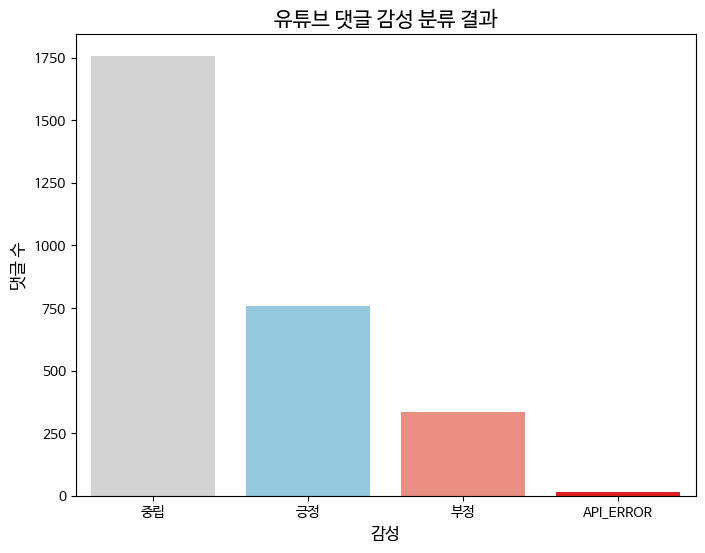


⚠️ API_ERROR 발생 건수: 16개. 해당 댓글은 확인이 필요합니다.


In [ ]:
# @title 7. 분석 결과 통계 및 시각화
if 'df_final' not in locals():
    if os.path.exists(FINAL_PATH):
        df_final = pd.read_csv(FINAL_PATH)
        print(f"최종 결과 파일 로드 완료: {FINAL_PATH}")
    else:
        print("❌ 최종 분석 결과 파일이 없어 분석을 건너뜁니다. Cell 6을 먼저 실행하세요.")
        df_final = None

if df_final is not None:
    # 1. 감성 분류 결과 집계
    sentiment_counts = df_final['sentiment'].value_counts(dropna=False)
    print("\n" + "="*40)
    print("--- 감성 분류 결과 요약 ---")
    print(sentiment_counts)
    print("="*40 + "\n")

    # 2. 시각화
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns

        plt.rcParams['font.family'] = 'NanumBarunGothic'
        plt.rcParams['axes.unicode_minus'] = False

        plot_data = sentiment_counts[sentiment_counts.index.isin(['긍정', '부정', '중립', 'API_ERROR'])]

        plt.figure(figsize=(8, 6))
        colors = {'긍정': 'skyblue', '부정': 'salmon', '중립': 'lightgray', 'API_ERROR': 'red'}
        sns.barplot(x=plot_data.index, y=plot_data.values, palette=[colors.get(i) for i in plot_data.index])

        plt.title('유튜브 댓글 감성 분류 결과', fontsize=15)  # 필요하면 여기 제목만 BHC용으로 바꿔도 됨
        plt.xlabel('감성', fontsize=12)
        plt.ylabel('댓글 수', fontsize=12)
        plt.show()

    except Exception as e:
        print(f"⚠️ 시각화 라이브러리 로드 또는 실행 실패: {e}")
        print("시각화 없이 통계만 출력합니다.")

    # 3. API_ERROR 발생 건수 확인
    error_count = (df_final['sentiment'] == 'API_ERROR').sum()
    if error_count > 0:
        print(f"\n⚠️ API_ERROR 발생 건수: {error_count}개. 해당 댓글은 확인이 필요합니다.")


In [ ]:
# @title 1. 전체 환경 설정 및 데이터 준비

# --- 1. 라이브러리 임포트 ---
import pandas as pd
import os
import time
from google.colab import drive, userdata, output
from IPython.display import display, clear_output, Markdown
import ipywidgets as widgets
from ipywidgets import HBox
import google.generativeai as genai

print("라이브러리 임포트 완료.")

# --- 2. Google Drive 마운트 ---
try:
    drive.mount('/content/drive')
    print("✅ Google Drive 마운트 성공.")
except Exception as e:
    print(f"❌ Google Drive 마운트 실패: {e}")

# --- 3. Gemini API 키 로드 및 클라이언트 초기화 ---
API_KEY_NAME = "gemini_key" # Colab Secrets에 저장된 API 키 이름
MODEL_NAME = "gemini-flash-latest" # 사용할 모델 이름
client = None

try:
    api_key = userdata.get(API_KEY_NAME)
    if not api_key:
        raise ValueError(f"'{API_KEY_NAME}' 이름의 API Key가 비어 있습니다.")

    # API 클라이언트 초기화
    genai.configure(api_key=api_key)
    client = genai.GenerativeModel(MODEL_NAME)
    print(f"✅ API Key 로드 및 '{MODEL_NAME}' 모델 클라이언트 초기화 성공.")

except Exception as e:
    print(f"❌ API Key 로드 또는 클라이언트 초기화 실패: {e}")
    print("Google Colab의 'Secrets(🔑)'에 API 키가 올바르게 설정되었는지 확인하세요.")

# --- 4. 최종 분석 파일 로드 ---
SAVE_DIR = "/content/drive/MyDrive/YoutubeData" # 올바른 저장 경로로 수정
FINAL_FILE_NAME = "통합_분석_결과.csv"
FINAL_PATH = os.path.join(SAVE_DIR, FINAL_FILE_NAME)
df_final = None

if os.path.exists(FINAL_PATH):
    df_final = pd.read_csv(FINAL_PATH)
    df_final['confidence'] = pd.to_numeric(df_final['confidence'], errors='coerce').fillna(0.0)
    df_final['sentiment'] = df_final['sentiment'].astype(str)
    print(f"✅ 최종 분석 파일 로드 성공: {FINAL_PATH} ({len(df_final)}개 댓글)")
else:
    print(f"❌ 최종 분석 파일을 찾을 수 없습니다. 원본 분석 코드를 먼저 실행하여 파일을 생성해주세요.")

# --- 5. Colab 위젯 활성화 ---
output.enable_custom_widget_manager()
print("\n모든 준비가 완료되었습니다. 다음 셀을 실행하여 컨트롤 패널을 표시하세요.")

라이브러리 임포트 완료.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive 마운트 성공.
✅ API Key 로드 및 'gemini-flash-latest' 모델 클라이언트 초기화 성공.
✅ 최종 분석 파일 로드 성공: /content/drive/MyDrive/YoutubeData/통합_분석_결과.csv (2868개 댓글)

모든 준비가 완료되었습니다. 다음 셀을 실행하여 컨트롤 패널을 표시하세요.


In [ ]:
# @title 2. 컨트롤 패널: 분석 조건 선택

# 분석 결과가 표시될 전용 출력 영역 위젯 생성
analysis_output_area = widgets.Output()

# Gemini 분석을 수행하는 함수 정의
def run_gemini_analysis(change):
    # 현재 위젯 값 가져오기
    sentiment = sentiment_dropdown.value
    confidence = confidence_slider.value

    # analysis_output_area 위젯 내부의 출력을 제어
    with analysis_output_area:
        clear_output(wait=True)
        print("🔄 Gemini가 분석 중입니다... 잠시만 기다려 주세요.")

        # 데이터 필터링
        filtered_df = df_final[(df_final['sentiment'] == sentiment) & (df_final['confidence'] >= confidence)].copy()
        filtered_count = len(filtered_df)

        if filtered_count == 0:
            clear_output(wait=True)
            display(Markdown(f"### ⚠️ 조건에 해당하는 댓글이 없습니다.\n- **선택 조건:** 감성=`{sentiment}`, Confidence Score >= `{confidence:.1f}`"))
            return

        # Gemini에게 전달할 대표 댓글 샘플링 (최대 10개)
        sample_df = filtered_df.sort_values(by='confidence', ascending=False).head(10)
        comment_examples = "\n".join([f"- {row['text']}" for _, row in sample_df.iterrows()])

        # Gemini에게 보낼 프롬프트 구성
        prompt = f"""
        당신은 'BBQ 치킨 신상' 유튜브 영상의 댓글 데이터를 분석하는 전문 데이터 분석가입니다.
        아래는 사용자가 필터링한 댓글 데이터의 요약 정보와 대표적인 댓글 예시입니다.
        이 내용을 바탕으로 심층적인 분석 리포트를 작성해주세요.

        **1. 분석 대상 데이터 요약:**
        - **선택된 감성:** {sentiment}
        - **선택된 Confidence Score 최소값:** {confidence:.1f}
        - **해당 조건의 댓글 수:** {filtered_count}개

        **2. 대표 댓글 예시:**
        {comment_examples}

        **3. 리포트 작성 지시사항 (아래 형식을 반드시 준수하여 Markdown으로 작성):**
        - **분석 요약 및 핵심 함의점:** 필터링된 댓글들의 핵심적인 의견이 무엇인지 1~2 문장으로 요약하고, 이것이 제품/서비스에 어떤 의미를 갖는지 설명해주세요.
        - **주요 하위 주제 클러스터링:** 댓글들에서 공통적으로 나타나는 3-4가지 핵심 주제(예: 디자인, 성능, 가격)를 추출하고, 각 주제에 대한 사용자들의 구체적인 의견을 설명해주세요.
        - **대표 의견:** 가장 대표적이거나 인상 깊은 댓글 2~3개를 인용하고, 왜 이 댓글이 중요하다고 생각하는지 간략히 부연 설명해주세요.
        """

        try:
            # Gemini API 호출
            response = client.generate_content(prompt)

            # 결과 출력 영역을 다시 한번 지우고 최종 결과 표시
            clear_output(wait=True)
            display(Markdown(f"### 🔮 Gemini 분석 리포트 (감성: {sentiment}, Confidence >= {confidence:.1f})"))
            display(Markdown(response.text))

        except Exception as e:
            clear_output(wait=True)
            display(Markdown(f"### ❌ Gemini API 호출 중 오류 발생\n- 오류 내용: {e}"))


# --- 위젯 생성 (셀 1에서 df_final이 로드된 경우에만 실행) ---
if 'df_final' in locals() and df_final is not None and client is not None:
    sentiment_dropdown = widgets.Dropdown(
        options=['긍정', '부정', '중립'], value='부정', description='감성 선택:', style={'description_width': 'initial'}
    )
    confidence_slider = widgets.FloatSlider(
        value=0.7, min=0.0, max=1.0, step=0.1, description='Confidence 최소값:', readout_format='.1f', style={'description_width': 'initial'}
    )

    # 위젯 값이 변경될 때마다 run_gemini_analysis 함수가 실행되도록 연결
    sentiment_dropdown.observe(run_gemini_analysis, names='value')
    confidence_slider.observe(run_gemini_analysis, names='value')

    # 이 셀에 컨트롤러 표시
    display(HBox([sentiment_dropdown, confidence_slider]))

    # 초기 로딩 시 분석 함수를 한 번 호출하여 초기 결과를 표시
    run_gemini_analysis(None)
else:
    print("❌ 분석을 시작할 수 없습니다. 셀 1을 실행하여 데이터와 API 클라이언트를 먼저 준비해주세요.")

In [ ]:
# @title 3. Gemini 실시간 분석 리포트

# 셀 2에서 생성하고 제어하는 analysis_output_area를 이 셀에 표시합니다.
# 위의 컨트롤 패널을 조작하면 이곳의 내용이 실시간으로 변경됩니다.

if 'analysis_output_area' in locals():
    display(analysis_output_area)
else:
    print("❌ 컨트롤 패널(셀 2)을 먼저 실행해주세요.")

Output()

In [ ]:
# @title 4. [자동화] 최적 Confidence 탐색 (Pro 모델 최종 분석)

import re
import time
from IPython.display import display, Markdown, clear_output

# --- 0. 실행 전 환경 확인 ---
if 'client' not in locals() or 'df_final' not in locals() or client is None or df_final is None:
    print("❌ 실행을 중단합니다. 셀 1을 먼저 실행하여 API 클라이언트와 데이터를 준비해주세요.")
else:
    # --- 1. 기본 분석 리포트 생성 (Flash 모델 사용) ---
    print("="*60)
    print(f"🤖 1단계: Flash 모델({client.model_name})로 12개 케이스의 기본 리포트를 생성합니다.")
    print("="*60)

    results_storage = {}
    sentiments_to_run = ['긍정', '부정']
    confidence_levels = [i / 10 for i in range(5, 11)] # 0.5 ~ 1.0

    for sentiment in sentiments_to_run:
        results_storage[sentiment] = {}
        for conf_level in confidence_levels:
            print(f"🔄 [{sentiment} / {conf_level:.1f}] 케이스 분석 중...")

            filtered_df = df_final[(df_final['sentiment'] == sentiment) & (df_final['confidence'] >= conf_level)]

            if len(filtered_df) < 3:
                report_text = "데이터 부족으로 분석을 건너뛰니다."
            else:
                sample_df = filtered_df.sort_values(by='confidence', ascending=False).head(10)
                comment_examples = "\n".join([f"- {row['text']}" for _, row in sample_df.iterrows()])

                prompt = f"""
                유튜브 댓글 데이터 분석 리포트를 작성해주세요.
                - 분석 대상: 감성='{sentiment}', Confidence Score >= {conf_level:.1f} (총 {len(filtered_df)}개)
                - 대표 댓글:
                {comment_examples}

                - 작성 지시: 위 데이터를 바탕으로 핵심 요약, 주요 주제, 대표 의견을 포함한 상세 분석 리포트를 Markdown 형식으로 작성.
                """
                try:
                    # 기본 분석은 기존의 client (Flash 모델) 사용
                    response = client.generate_content(prompt)
                    report_text = response.text
                except Exception as e:
                    report_text = f"API 오류: {e}"

            results_storage[sentiment][conf_level] = report_text
            time.sleep(1)

    print("\n✅ 1단계: 기본 리포트 생성을 완료했습니다.")

    # --- 2. 최종 결론 도출 (Pro 모델 사용) ---
    print("\n\n" + "="*60)
    print(f"🤖 2단계: Pro 모델(gemini-2.5-pro)로 최종 결론을 도출합니다.") # 모델 이름 업데이트
    print("="*60)

    try:
        # 사용 가능한 모델 목록 출력 (디버깅용)
        print("사용 가능한 모델 목록:")
        for m in genai.list_models():
            if "generateContent" in m.supported_generation_methods:
                print(f"- {m.name}")

        # 이 단계에서만 Pro 모델 클라이언트를 별도로 초기화
        PRO_MODEL_NAME = "gemini-2.5-pro" # 모델 이름을 'gemini-2.5-pro'로 변경
        pro_client = genai.GenerativeModel(PRO_MODEL_NAME)
        print(f"✅ 고급 분석을 위해 '{PRO_MODEL_NAME}' 모델을 준비했습니다.")
    except Exception as e:
        print(f"❌ Pro 모델 초기화 실패: {e}. 실행을 중단합니다.")
        # Pro 모델이 없으면 실행 중단
        pro_client = None

    if pro_client:
        best_reports_analysis = {}

        for sentiment in sentiments_to_run:
            print(f"\n▶️ '{sentiment}' 감성의 베스트 리포트를 Pro 모델이 심층 분석 중... (시간이 소요될 수 있습니다)")

            reports_to_evaluate = ""
            for conf_level, report in results_storage[sentiment].items():
                reports_to_evaluate += f"\n\n--- [리포트 후보 {conf_level:.1f}] ---\n{report}"

            # Pro 모델의 'Thinking Budget'을 최대로 활용하기 위한 고도화된 프롬프트
            evaluation_prompt = f"""
            당신은 수석 데이터 과학자(Principal Data Scientist)입니다.
            주니어 분석가들이 동일한 '{sentiment}' 감성 데이터에 대해 Confidence 임계값만 다르게 설정하여 아래와 같이 6개의 분석 리포트 초안을 제출했습니다.
            당신의 임무는 이 6개의 초안을 면밀히 검토하여, 비즈니스 의사결정에 가장 큰 영감을 줄 수 있는 단 하나의 '베스트 리포트'를 선정하고 그 이유를 종합적으로 설명하는 것입니다.

            **[평가 대상 리포트 목록]**
            {reports_to_evaluate}

            **[최종 보고서 작성 지시사항]**
            아래 형식에 맞춰 Markdown으로 상세한 최종 보고서를 작성해주세요. 당신의 깊이 있는 추론 능력을 보여주세요.

            1.  **최적의 Confidence 임계값:**
                - 베스트 리포트에 해당하는 Confidence 임계값을 숫자(예: `0.7`) 하나만 명시해주세요.

            2.  **선정 핵심 이유 (Executive Summary):**
                - 왜 해당 Confidence 임계값의 리포트가 가장 뛰어난지 2~3문장으로 요약해주세요. (예: 노이즈를 효과적으로 제거하면서도 핵심 의견을 충분히 포착했기 때문...)

            3.  **심층 비교 분석:**
                - **선정된 리포트의 강점:** 이 리포트가 다른 리포트들에 비해 구체적으로 어떤 점에서 뛰어난지 (예: 발견된 주제의 구체성, 제시된 의견의 대표성, 숨겨진 인사이트 발견 등) 상세히 분석해주세요.
                - **탈락한 리포트들의 한계점:** 너무 낮거나 높은 임계값의 리포트들이 왜 최적으로 선택되지 못했는지 구체적인 이유를 비교하며 설명해주세요. (예: 0.5는 너무 일반적인 의견이 많아 핵심 파악이 어렵고, 1.0은 의견이 너무 편향되어 전체를 대변하지 못함 등)
            """

            try:
                # Pro 모델을 사용하여 최종 결론 도출
                eval_response = pro_client.generate_content(evaluation_prompt)
                best_reports_analysis[sentiment] = eval_response.text
            except Exception as e:
                best_reports_analysis[sentiment] = f"평가 중 API 오류 발생: {e}"
            time.sleep(1)

        # --- 3. 최종 결과 보고 ---
        clear_output(wait=True)
        print("="*60)
        print("🏆 [Pro 모델] 최종 자동 분석 및 평가 결과 🏆")
        print("="*60 + "\n")

        for sentiment in sentiments_to_run:
            display(Markdown(f"## 💎 `{sentiment}` 감성 분석 최종 결론"))

            # Pro 모델이 생성한 통찰력 있는 분석 결과 전체를 그대로 출력
            analysis_result = best_reports_analysis.get(sentiment, "결과를 가져오는 데 실패했습니다.")
            display(Markdown(analysis_result))

            # 베스트 리포트 원문도 함께 표시
            try:
                # Pro 모델의 답변에서 최적 Confidence 값 추출
                best_conf_str = re.search(r'(\d\.\d)', analysis_result)
                if best_conf_str:
                    best_conf = float(best_conf_str.group(1))
                    best_report_text = results_storage[sentiment].get(best_conf, "리포트를 가져올 수 없습니다.")
                else:
                    best_report_text = "베스트 리포트 원문을 자동으로 표시하는 데 실패했습니다. (Confidence 값 추출 불가)"

                display(Markdown(f"\n---\n"))
                display(Markdown(f"### 📄 참고: 선정된 베스트 리포트 원문 (Flash 모델 작성본)"))
                display(Markdown(best_report_text))
            except Exception as e:
                # 숫자 추출 실패 시 원문 표시는 건너뛰기
                display(Markdown(f"*베스트 리포트 원문을 자동으로 표시하는 데 실패했습니다. 오류: {e}*"))

            display(Markdown(f"\n" + "="*80 + "\n"))

🏆 [Pro 모델] 최종 자동 분석 및 평가 결과 🏆



## 💎 `긍정` 감성 분석 최종 결론

훌륭한 과제입니다. 주니어 분석가들의 작업을 검토하고 최적의 비즈니스 가치를 창출하는 리포트를 선정하는 것은 수석 데이터 과학자의 핵심적인 역할 중 하나입니다. 6개의 리포트를 면밀히 검토한 후, 아래와 같이 최종 보고서를 작성합니다.

---

### **최종 보고서: 최적 유튜브 댓글 분석 리포트 선정 및 종합 평가**

### 1. 최적의 Confidence 임계값

`0.7`

### 2. 선정 핵심 이유 (Executive Summary)

Confidence 임계값 0.7을 기준으로 작성된 **[리포트 후보 0.7]**을 베스트 리포트로 선정합니다. 이 리포트는 유의미한 노이즈를 효과적으로 제거하면서도, 비즈니스 의사결정에 필수적인 핵심 주제와 의견의 다양성을 충분히 포착하는 최적의 균형점(Sweet Spot)을 보여주었습니다. 특히, 단순한 감성 분류를 넘어 '크리에이터에 대한 충성심'이 '광고 제품에 대한 긍정적 수용'으로 직접 연결되는 핵심적인 비즈니스 메커니즘을 가장 명확하게 통찰해냈습니다.

### 3. 심층 비교 분석

#### **선정된 리포트의 강점 (리포트 0.7, N=587)**

[리포트 후보 0.7]은 다른 모든 리포트를 능가하는 몇 가지 결정적인 강점을 가지고 있습니다.

1.  **최적의 신호 대 잡음비 (Optimal Signal-to-Noise Ratio):**
    데이터 분석에서 임계값 설정은 '신호(Signal)'와 '잡음(Noise)' 사이의 균형을 맞추는 과정입니다. 0.7 임계값은 587건이라는 충분히 대표성 있는 데이터 양을 확보하면서, 0.5나 0.6에서 보일 수 있는 애매하거나 약한 긍정 반응(잡음)을 효과적으로 필터링했습니다. 이로 인해 분석된 주제들이 매우 명확하고 응집력이 높습니다.

2.  **가장 전략적인 비즈니스 인사이트 도출:**
    이 리포트의 백미는 **'주제 3.3. 광고 및 제품에 대한 최상급의 수용'** 파트입니다. 다른 리포트들이 '제품 찬양'이라는 현상 자체에 머물렀다면, 0.7 리포트는 이를 **'크리에이터에 대한 애정을 바탕으로 해당 제품에 가치를 부여하는 경향'**이라고 정확히 해석했습니다. 이는 "우리 PPL/광고는 왜 성공적인가?"라는 질문에 '팬덤의 신뢰 전이(Trust Transfer)'라는 구체적인 답을 제공하는, 매우 높은 수준의 전략적 인사이트입니다.

3.  **구체적이고 다각적인 주제 분류:**
    0.7 리포트는 긍정 감성의 동인을 ①인물(Creator Loyalty), ②콘텐츠 경험(Sensory Focus), ③상업적 결과(Positive Ad Reception)라는 세 가지 핵심 축으로 명확하게 구조화했습니다. 이러한 구조화는 현상을 체계적으로 이해하게 하고, 각 영역에 맞는 후속 액션 아이템(예: 인물 중심 마케팅 강화, ASMR 퀄리티 향상, PPL 제품군 확대 등)을 도출하기에 가장 용이합니다.

4.  **창의적 참여(삼행시)의 의미 해석:**
    단순히 '재치 있는 삼행시가 있다'고 언급한 다른 리포트들과 달리, 0.7 리포트는 이를 '창의적인 방식으로 제품을 홍보'하고 '즉각적인 구매 행동을 촉구'하는 팬들의 자발적인 참여 행위로 깊이 있게 해석했습니다. 이는 단순한 긍정 반응을 넘어, 팬들이 브랜드의 '앰배서더(Ambassador)' 역할을 하고 있음을 시사하는 중요한 발견입니다.

#### **탈락한 리포트들의 한계점**

##### **A. 임계값이 너무 낮아 '핵심'이 희석된 경우 (리포트 0.5, 0.6)**

*   **리포트 0.5 (N=728):** "폭발적인 감성 표현"이나 "인물에 대한 애정" 등 가장 보편적인 주제를 발견했지만, 그 강도와 맥락이 다소 평면적입니다. 데이터 양이 많아 일반론적인 결론에 그칠 위험이 있으며, 대표 의견에 포함된 "didi gi"와 같은 부분은 분석의 신뢰도를 저하시킬 수 있는 잠재적 노이즈입니다.
*   **리포트 0.6 (N=708):** 0.5보다 발전하여 '글로벌 팬덤'이나 '과장법 사용' 등 구체적인 특징을 잘 포착했습니다. 특히 일본어의 '様' 사용 등 언어별 특징 분석은 훌륭합니다. 하지만 0.7 리포트가 발견한 '광고 수용성'이라는 핵심적인 비즈니스 동인까지는 도달하지 못하고, 현상 기술에 더 집중하는 한계를 보입니다.

##### **B. 임계값이 너무 높아 '편향'되고 '다양성'을 잃은 경우 (리포트 0.8, 0.9, 1.0)**

*   **리포트 0.8 (N=493):** 매우 훌륭한 리포트이며 0.7과의 경합이 가장 치열했습니다. 특히 '뿌링클을 넘어서는...'이라는 경쟁사 비교 의견과 'Eng sub' 요청이라는 구체적인 VOC(고객의 소리)를 발견한 것은 큰 장점입니다. 그럼에도 불구하고 0.7에 비해 종합적인 스토리텔링, 즉 '팬덤의 신뢰가 어떻게 비즈니스 성과로 이어지는가'에 대한 통찰의 깊이가 다소 부족했습니다. 개별적인 발견은 훌륭했으나, 이를 관통하는 핵심 메커니즘 제시는 0.7이 더 뛰어났습니다.

*   **리포트 0.9 (N=295):** 데이터 수가 300건 미만으로 줄어들면서, '열성 팬(Hard-core Fan)'의 의견에 과도하게 집중하기 시작합니다. 분석 내용이 '폭발적 이모티콘 사용', 'ASMR 사운드 품질' 등 더욱 미시적이고 기술적인 부분에 치우치는 경향을 보입니다. 이는 분명 유의미한 분석이지만, 전체 긍정 여론의 폭넓은 스펙트럼을 대표하기에는 다소 편향된 시각일 수 있습니다.

*   **리포트 1.0 (N=4):** **통계적 함정**의 전형적인 예시입니다. 단 4개의 샘플은 '분석'이 아닌 '일화(Anecdote)'에 불과합니다. 이 데이터는 "가장 확실한 긍정은 이런 형태이다"라는 예시를 보여줄 수는 있지만, 이를 바탕으로 전체 긍정 여론에 대한 일반화된 결론이나 비즈니스 전략을 도출하는 것은 매우 위험합니다. 이 리포트는 대표성을 완전히 상실했습니다.

---
결론적으로, **리포트 0.7**은 데이터의 양과 질, 분석의 깊이, 그리고 비즈니스 전략과의 연계성 측면에서 가장 완벽한 균형을 이루었기에, 최종 베스트 리포트로 선정하는 바입니다. 해당 리포트를 작성한 분석가에게는 칭찬과 함께, 이 인사이트를 바탕으로 한 후속 분석(예: 팬덤 충성도와 실제 PPL 제품 매출 데이터 간의 상관관계 분석)을 제안할 것입니다.


---


### 📄 참고: 선정된 베스트 리포트 원문 (Flash 모델 작성본)

...

알겠습니다. 수석 데이터 과학자로서 제출된 6개의 리포트 초안을 면밀히 검토했습니다. 분석의 깊이, 비즈니스 연관성, 그리고 노이즈와 시그널의 균형을 종합적으로 고려하여 최적의 리포트를 선정하고 그 이유를 아래와 같이 보고합니다.

---

### 1. 최적의 Confidence 임계값:

`0.7`

### 2. 선정 핵심 이유 (Executive Summary):

Confidence 임계값 0.7을 적용한 리포트는 비즈니스 의사결정에 가장 큰 가치를 제공합니다. 이 리포트는 무의미한 노이즈와 모호한 불만(낮은 임계값의 한계)을 효과적으로 제거하면서도, 분석에 필요한 핵심 부정 의견의 폭과 깊이를 충분히 확보(높은 임계값의 한계 극복)하는 최적의 균형점을 찾았기 때문입니다. 그 결과, '브랜드 적대감'과 '가치 제안 실패'라는 매우 구체적이고 전략적인 인사이트를 도출해냈습니다.

### 3. 심층 비교 분석:

#### **선정된 리포트(0.7)의 강점:**

임계값 0.7 리포트는 다른 리포트들과 비교하여 다음과 같은 명백한 우수성을 보입니다.

*   **1. 전략적 주제의 발견 (Discovery of Strategic Themes):**
    단순히 '가격 불만', '품질 불만'을 나열하는 수준을 넘어, 이를 **'가치 제안(Value Proposition) 실패'**와 **'브랜드 적대감(Brand Hostility)'**이라는 비즈니스 전략 차원의 개념으로 격상시켰습니다. 이는 경영진이 문제의 심각성을 즉각적으로 인지하고 마케팅, R&D, 운영 등 전사적 차원의 대응을 고려하게 만드는 매우 강력한 인사이트입니다.

*   **2. 최적의 신호 대 잡음비 (Optimal Signal-to-Noise Ratio):**
    266개라는 표본 크기는 분석의 신뢰도를 담보할 만큼 충분히 크면서도, 의미 없는 비난이나 콘텐츠 자체에 대한 비판 등 핵심과 무관한 '잡음'을 상당수 걸러냈습니다. 그 결과, "그냥 치킨 다 튀기고나서 가루 뿌리는 조리과정"과 같은 제품의 근본적인 문제점을 지적하는 '강력한 신호'에 집중할 수 있었습니다.

*   **3. 구체성과 대표성의 완벽한 조화:**
    이 리포트는 "콰삭킹 첫날 먹고 너무 맛있어서 다음날 다른 지점에서 시켰는데 기름에 절어서 못먹고..."와 같이 소비자의 구체적인 실패 경험을 생생하게 담아내면서도, 이러한 경험이 특정 개인의 문제가 아닌 '일관성 없는 품질'이라는 보편적인 문제임을 명확히 연결합니다. 즉, 개별 의견의 구체성과 전체를 아우르는 대표성을 모두 확보했습니다.

#### **탈락한 리포트들의 한계점:**

*   **임계값이 너무 낮은 리포트 (0.5, 0.6)의 한계점:**
    *   **핵심 메시지 희석:** 330개, 324개라는 많은 데이터를 포함했지만, "Workdol 채널 운영 비판", "아이돌 게스트" 등 제품/브랜드와 직접적인 관련이 적은 의견들이 섞여 들어왔습니다. 이로 인해 치킨 브랜드가 해결해야 할 핵심 문제(품질, 가격)에 대한 집중도가 떨어지고 분석이 산만해지는 경향을 보입니다.
    *   **피상적인 분석:** 데이터가 많다 보니 개별 의견의 깊이 있는 분석보다는 현상을 나열하는 데 그칠 위험이 큽니다. '부정'으로 분류되긴 했지만, 그 강도가 약하거나 모호한 의견들까지 포함되어 문제의 심각성이 오히려 희석될 수 있습니다.

*   **임계값이 너무 높은 리포트 (0.8, 0.9, 1.0)의 한계점:**
    *   **주제의 분절 및 편향성 심화 (0.8):** 186개로 표본이 줄어들자, 제품/브랜드 비판 외에 "콘텐츠 질 저하", "외부 사회 이슈" 등 다른 주제의 비중이 상대적으로 커지는 '주제의 분절' 현상이 나타났습니다. 이는 전체 부정 여론의 핵심 흐름을 오해하게 만들 수 있는 심각한 왜곡입니다.
    *   **과적합 및 대표성 상실 (0.9, 1.0):** 94개, 특히 3개라는 극소수의 표본은 '분석'이 아닌 '사례 연구'에 가깝습니다. 이 리포트들은 가장 극단적이고 원색적인 비난(예: "고아 기업")에만 초점을 맞추게 되어, 전체 부정 여론을 과도하게 폭력적인 소수의 의견으로만 대표하는 **표본 편향(Sample Bias)** 오류를 범하게 됩니다. 이러한 극단적 의견에만 기반하여 비즈니스 전략을 수립하는 것은 매우 위험합니다. 리포트 1.0은 문제의 존재를 '확인'시켜줄 수는 있으나, 문제의 '규모'와 '양상'을 설명해주지는 못합니다.

결론적으로, 임계값 0.7 리포트는 주니어 분석가들이 흔히 빠지기 쉬운 '데이터가 많을수록 좋다'는 함정(0.5, 0.6)과 '가장 강한 목소리만 듣는' 함정(0.9, 1.0)을 모두 피한, 가장 균형 잡히고 통찰력 있는 분석을 제시했습니다. 따라서 이 리포트를 최종안으로 채택하고, 이를 기반으로 즉각적인 액션 플랜 수립을 추진할 것을 제언합니다.


---


### 📄 참고: 선정된 베스트 리포트 원문 (Flash 모델 작성본)

# 유튜브 댓글 데이터 분석 리포트: 부정 감성 집중 분석

## 1. 리포트 개요

본 리포트는 유튜브 콘텐츠에 달린 댓글 중 **감성 평가가 '부정'**으로 분류되었으며, 분석 신뢰도(Confidence Score)가 0.7 이상인 266개의 데이터를 집중 분석한 결과입니다. 표본 데이터는 특정 치킨 브랜드(주로 BBQ) 및 제품에 대한 소비자의 강한 불만과 적대감을 명확하게 보여줍니다.

---

## 2. 핵심 요약 (Executive Summary)

분석 결과, 소비자의 부정적 감성은 단순한 불만을 넘어 **극도의 적대감(Brand Hostility)** 수준에 도달해 있으며, 이는 제품의 **일관성 없는 품질**과 기업의 **가치 제안(Value Proposition) 실패**에서 기인합니다.

| 분류 | 주요 요약 |
| :--- | :--- |
| **품질 및 일관성** | 지점별 편차가 심하며, 튀김 상태(기름에 절음, 탐), 염도(과도한 짠맛) 등 기본적인 제품 품질 관리가 실패하여 강한 실망감을 유발. |
| **가격 및 가치** | 유종 변경(혼합유 사용 의혹)에도 불구하고 가격을 인상하는 행태에 대해 소비자들이 '배신'으로 인식하며, 현재 가격 대비 제품 가치가 현저히 낮다고 판단함. |
| **브랜드 적대감** | "BBQ는 믿거", "역겨운", "곱게 사라져라" 등 브랜드를 향한 극단적인 거부 반응과 혐오 표현이 다수 발생. 광고나 이벤트에 대한 면역도가 높음. |

---

## 3. 주요 분석 주제 및 상세 의견

수집된 부정 댓글 266건은 크게 **품질 및 일관성 문제, 가격 대비 가치 저하, 그리고 브랜드 자체에 대한 적대감**의 세 가지 축으로 분류됩니다.

### 3.1. [주제 1] 일관성 없는 품질 및 맛의 실패 (Quality & Taste Failure)

가장 빈번하게 언급된 부정 의견은 제품을 구매할 때마다 경험하는 품질의 극심한 편차와 기본 맛에 대한 불만이었습니다. 특히 튀김 방식과 염지 과정에 대한 비판이 높습니다.

| 세부 주제 | 대표 의견 (발췌) | 분석 인사이트 |
| :--- | :--- | :--- |
| **콰삭함 실패** | "콰삭킹 첫날 먹고 너무 맛있어서 다음날 다른 지점에서 시켰는데 기름에 절어서 못먹고... 타서와서 못먹고" | 특정 신제품이 가졌던 잠재적 만족도가 일관성 없는 조리 상태(기름짐, 탐)로 인해 완전히 상실됨. 이는 가맹점 관리의 문제로 직결됨. |
| **과도한 염도/인공성** | "이거 너무 짯어요....", "짠맛이 너무 감돌고 먹고나서 체감이 확실히 일반 치킨보다도 더 더럽고 헤비함" | 강한 짠맛과 인공적인 조미료 사용으로 인해 쉽게 물리고 속이 더부룩하다는 의견이 지배적입니다. |
| **조리 방식 비판** | "양념을 더 할 때 마리네이드나, 재워나서 스며든게 아니라 그냥 치킨 다 튀기고나서 가루 뿌리고선 몇천원 더 받는 조리과정" | 염지 대신 겉면에만 시즈닝을 뿌리는 방식이 풍미의 깊이를 떨어뜨리고, 과자 같은 식감을 유발하며, 이는 원가 절감 행위로 인식되어 불만을 가중시킴. |

### 3.2. [주제 2] 가격 대비 가치 상실 (Price & Value Proposition Loss)

소비자들은 가격 인상에 매우 민감하게 반응하며, 특히 원재료의 품질 저하가 의심되는 상황에서 가격을 올리는 행위에 대해 강한 불신을 표출했습니다.

| 세부 주제 | 대표 의견 (발췌) | 분석 인사이트 |
| :--- | :--- | :--- |
| **가격 역설 비판** | "혼합유로 바꿨으면 가격을 내려야지 쳐 올리네" | 혼합유(또는 저가 오일) 사용 의혹이 제기된 상황에서 가격 인상 단행은 소비자를 기만하는 행위로 인식되며, 비용 절감 효과가 소비자에게 전혀 환원되지 않는다는 불만이 폭발함. |
| **광고/이벤트 무력화** | "아무리 광고를 하고 이벤트를 해도 bbq는 안 사먹습니다..." | 높은 가격과 낮은 품질로 인해 형성된 부정적 이미지는 일시적인 광고나 이벤트로 회복되지 않는 '학습된 불신' 상태에 있음. |

### 3.3. [주제 3] 극도의 브랜드 적대감 및 거부 (Extreme Brand Hostility)

가장 눈에 띄는 특징은 제품의 단점을 넘어 기업의 윤리성, 이미지 자체에 대한 근본적인 거부감입니다. 이는 단순히 구매하지 않는 것을 넘어, 브랜드를 적극적으로 비난하고 퇴출되기를 바라는 수준의 적대감입니다.

| 세부 주제 | 대표 의견 (발췌) | 분석 인사이트 |
| :--- | :--- | :--- |
| **맹목적 불매 선언** | "BBQ는 믿거", "역겨운 bbq 안먹어서 응원하자" | 특정 브랜드를 향한 '무조건 거름'이라는 확신범적 태도가 형성됨. 이는 장기적인 소비자 이탈을 예고함. |
| **비윤리적 이미지 공격** | "뿜 뿜하고 부모없음을 티내는... 킹 킹받게 하지말고 곱게 사라져라 BBQ" | 극단적인 비난과 조롱을 통해 브랜드 이미지를 훼손하고 있으며, 이는 온라인 상에서 매우 빠르게 확산될 수 있는 위험성을 내포함. |
| **리뷰/광고 불신** | "구라치지마라 알바비 얼마받앗냐" | PPL, 유료 광고, 긍정적인 리뷰 자체를 믿지 않으며, 모든 마케팅 활동을 조작으로 간주하는 회의적인 시각이 만연함. |

---

## 4. 결론 및 제언

### 4.1. 결론

분석된 부정 댓글 데이터 266건은 소비자들이 특정 치킨 브랜드에 대해 **품질 불안정성(Inconsistency)**과 **가치 저하(Poor Value)**에 근거한 극심한 심리적 거리감을 느끼고 있음을 입증합니다. 이러한 부정 감성은 쉽게 사라지지 않는 강력한 거부 의사로 전환되었으며, 일반적인 마케팅 활동으로는 회복이 불가능한 수준입니다.

### 4.2. 제언

1. **품질 통제 시스템 재정립:** 지점별 품질 편차(튀김 상태, 염도)를 최소화할 수 있도록 조리 매뉴얼 및 가맹점 관리 시스템에 대한 즉각적이고 강력한 개입이 필요합니다.
2. **투명한 원가 및 가격 정책:** 유종 변경이나 원재료 이슈 발생 시, 가격 정책과의 연관성을 투명하게 공개하고 소비자가 납득할 수 있는 가치 제안을 명확히 해야 합니다.
3. **브랜드 이미지 쇄신 (진정성 확보):** 공격적인 마케팅보다는 품질 개선과 고객 피드백 수용을 통해 진정성을 보여주는 것이 장기적인 브랜드 적대감을 해소하는 유일한 방안입니다.


================================================================================
